In [1]:
# Setup environment and import paths
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE

# Add project root to path to access the 'src' module
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Import our custom topological tools
from src import compute_complexity_metrics, topological_ratio_optimizer

import warnings
warnings.filterwarnings('ignore')

print("Environment ready. Modules loaded successfully.")

Environment ready. Modules loaded successfully.


In [2]:
# Generate a highly imbalanced and overlapping 2D dataset
X, y = make_classification(
    n_samples=1500, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0, 
    n_clusters_per_class=2, 
    weights=[0.95, 0.05], # 95% Majority, 5% Minority
    class_sep=0.8,        # Low separation to force topological overlap
    random_state=42
)

classes, counts = np.unique(y, return_counts=True)
min_class = classes[np.argmin(counts)]
maj_class = classes[np.argmax(counts)]

print(f"Total instances: {len(y)}")
print(f"Majority Class ({maj_class}): {counts[np.argmax(counts)]} instances")
print(f"Minority Class ({min_class}): {counts[np.argmin(counts)]} instances")

Total instances: 1500
Majority Class (0): 1421 instances
Minority Class (1): 79 instances


In [3]:
# Audit the original topological space
metrics_min = compute_complexity_metrics(X, y, target_class=min_class)
metrics_maj = compute_complexity_metrics(X, y, target_class=maj_class)

print("--- Initial Topological Audit ---")
print(f"Minority Class Vulnerability (dwCM9): {metrics_min['dwCM9']:.4f}")
print(f"Majority Class Vulnerability (dwCM9): {metrics_maj['dwCM9']:.4f}")
print(f"Absolute Difference: {abs(metrics_min['dwCM9'] - metrics_maj['dwCM9']):.4f}")

--- Initial Topological Audit ---
Minority Class Vulnerability (dwCM9): 0.6076
Majority Class Vulnerability (dwCM9): 0.0329
Absolute Difference: 0.5747


In [4]:
# Run the topological optimizer to find the ideal sampling ratio
print("Running Barella-HARS Optimizer...")
optimal_ratio, history_df = topological_ratio_optimizer(X, y, theta=0.05, step=0.05)

print(f"\nCalculated Optimal Ratio: {optimal_ratio:.3f}")

# Display the search history
display(history_df)

Running Barella-HARS Optimizer...

Calculated Optimal Ratio: 0.406


,Ratio,C_min_dwCM9,C_maj_dwCM9,Absolute_Difference
0,0.106,0.357333,0.042787,0.314547
1,0.156,0.248869,0.052076,0.196793
2,0.206,0.193151,0.059958,0.133193
3,0.256,0.166942,0.064884,0.102058
4,0.306,0.138710,0.066573,0.072137
5,0.356,0.121584,0.070936,0.050648
6,0.406,0.108681,0.076566,0.032115


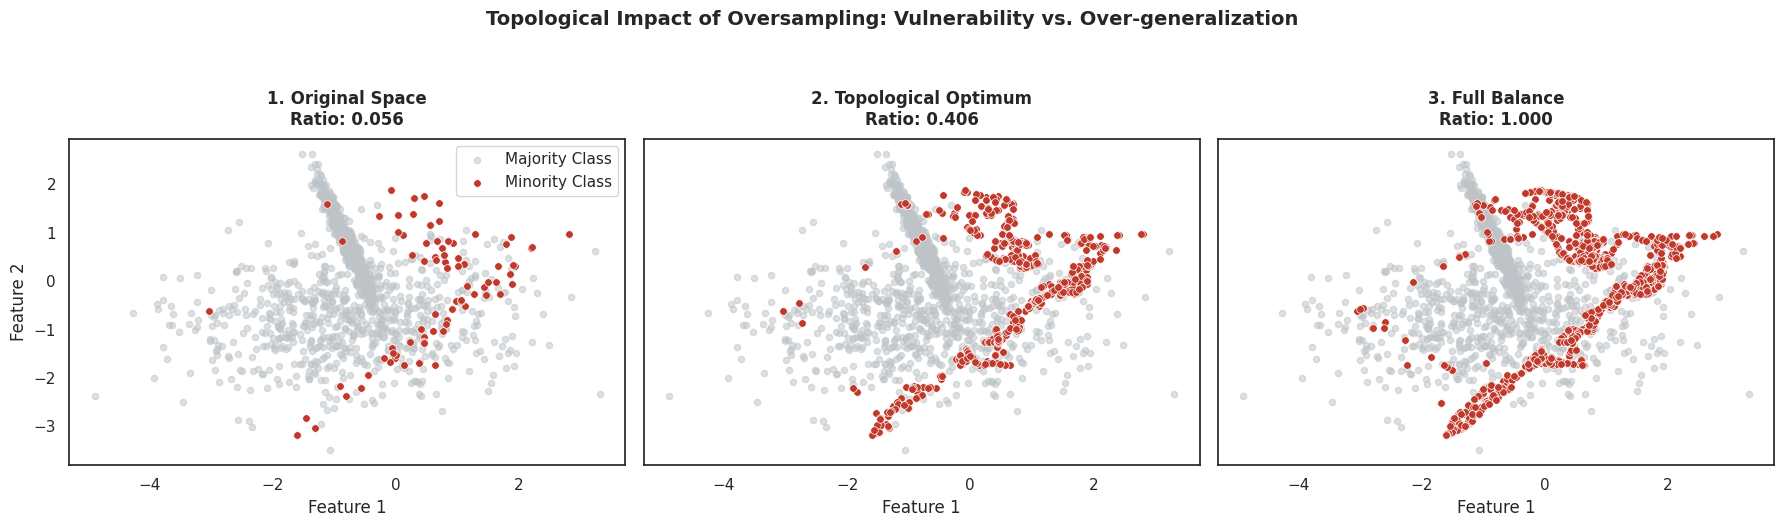

In [5]:
# Apply SMOTE with Optimal Ratio vs Full Balance
smote_opt = SMOTE(sampling_strategy=optimal_ratio, random_state=42)
X_opt, y_opt = smote_opt.fit_resample(X, y)

smote_full = SMOTE(sampling_strategy=1.0, random_state=42)
X_full, y_full = smote_full.fit_resample(X, y)

# Visualization setup
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

datasets = [
    (X, y, f"1. Original Space\nRatio: {counts[np.argmin(counts)]/counts[np.argmax(counts)]:.3f}"),
    (X_opt, y_opt, f"2. Topological Optimum\nRatio: {optimal_ratio:.3f}"),
    (X_full, y_full, "3. Full Balance\nRatio: 1.000")
]

color_maj = '#bdc3c7' # Light gray for majority
color_min = '#c0392b' # Dark red for minority

for i, ax in enumerate(axes):
    X_plot, y_plot, title = datasets[i]
    
    # Plot majority class in background
    ax.scatter(X_plot[y_plot == maj_class][:, 0], X_plot[y_plot == maj_class][:, 1], 
               c=color_maj, alpha=0.5, s=20, label='Majority Class' if i==0 else "")
    
    # Plot minority class in foreground
    ax.scatter(X_plot[y_plot == min_class][:, 0], X_plot[y_plot == min_class][:, 1], 
               c=color_min, edgecolor='white', linewidth=0.5, s=30, label='Minority Class' if i==0 else "")
    
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Feature 1')
    if i == 0:
        ax.set_ylabel('Feature 2')
        ax.legend(loc='upper right')

plt.suptitle('Topological Impact of Oversampling: Vulnerability vs. Over-generalization', 
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()